In [1]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader, ConcatDataset
import matplotlib.pyplot as plt
import glob
from tqdm import tqdm

# sys.path.append(os.path.dirname(os.getcwd()))

from Messy_data_Training_conditional_score import ConditionalScoreNet, hyvarinen_loss, compute_hyvarinen_score
from MoCapAnimateAsfAmc import MotionCapture

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Configuration
hidden_dim = 512
num_layers = 4
batch_size = 128
num_epochs = 300
lr = 5e-5
d = 93  # dimension of each frame
M = 1e6  # truncation level
b = 25*M

# Paths
root_dir = r"C:\Users\chenw\OneDrive - University of Pittsburgh\_score network code\Markov chain neumeric\CMU motion capture\training_amc"
save_dir = root_dir
hybrid_path = os.path.join(save_dir, "running_basketball_hybrid_path.pt")
score_output_path = os.path.join(save_dir, "running_basketball_score_difference.pt")


# Trial configuration
training_sets = {
    "running": {
        "02": ["03"],
        "09": [f"{i:02d}" for i in range(1, 12)],
        "16": ["08"] + [f"{i:02d}" for i in range(35, 47)] + [f"{i:02d}" for i in range(48, 58)],
        "35": [f"{i:02d}" for i in range(17, 26)], # trial 26 for testing
        "38": ["03"] # "38" for testing.
    },
    "basketball": {
        "06": [f"{i:02d}" for i in range(2, 15)]  # 02-14 for training, 15 for testing. 
    },
    "jumping": {
        "13": ["11", "13", "19", "32", "39", "40", "41" ], 
        "16": [f"{i:02d}" for i in range(1, 11)], 
        "49": ["02", "03"], 
    }
}

testing_sets = {
"running": {
    "35": ["26"] 
},
"basketball": {
    "06": ["15"] 
}, 
"jumping": {
    "13": ["42"]
}
}

In [3]:
def generate_hybrid_path(P0_class, P1_class, P0_subject, P0_trial, P1_subject, P1_trial, save_dir):
    print(f"\n=== Generating hybrid path: {P0_class} → {P1_class} ===")
    P0_asf = os.path.join(root_dir, P0_class, f"Subject_{P0_subject}", f"{P0_subject}.asf")
    P0_amc = os.path.join(root_dir, P0_class, f"Subject_{P0_subject}", f"Trial_{P0_trial}.amc")

    P1_asf = os.path.join(root_dir, P1_class, f"Subject_{P1_subject}", f"{P1_subject}.asf")
    P1_amc = os.path.join(root_dir, P1_class, f"Subject_{P1_subject}", f"Trial_{P1_trial}.amc")

    motion_0 = MotionCapture(P0_asf, P0_amc)
    T0, B0, _ = motion_0.data.shape
    X0 = motion_0.data.reshape(T0, B0 * 3)

    motion_1 = MotionCapture(P1_asf, P1_amc)
    T1, B1, _ = motion_1.data.shape
    X1 = motion_1.data.reshape(T1, B1 * 3)

    assert B0 == B1, "Mismatch in bone count"

    X_hybrid = torch.tensor(np.concatenate([X0, X1], axis=0), dtype=torch.float32)
    hybrid_path = os.path.join(save_dir, f"hybrid_path_{P0_class}_to_{P1_class}.pt")
    torch.save(X_hybrid, hybrid_path)
    print(f"Saved hybrid path to: {hybrid_path}")
    print(f"Shape: {X_hybrid.shape} = ({T0}+{T1}, {B0*3})")
    return hybrid_path, T0


In [48]:
def test_hyvarinen_difference(P0_class, P1_class, hybrid_path, T0):
    print(f"\n=== Testing {P0_class} → {P1_class} ===")
    X = torch.load(hybrid_path).float().to(device)
    x_pairs, y_pairs = X[:-1], X[1:]

    P0_model_path = get_model_path(f"{hidden_dim}_{num_layers}_{P0_class}.pth")
    P1_model_path = get_model_path(f"{hidden_dim}_{num_layers}_{P1_class}.pth")

    model_P0 = ConditionalScoreNet(d, hidden_dim, num_layers).to(device)
    model_P1 = ConditionalScoreNet(d, hidden_dim, num_layers).to(device)
    model_P0.load_state_dict(torch.load(P0_model_path, map_location=device))
    model_P1.load_state_dict(torch.load(P1_model_path, map_location=device))
    model_P0.eval()
    model_P1.eval()

    with torch.no_grad():
        score_p0 = compute_hyvarinen_score(model_P0, x_pairs, y_pairs, device)
        score_p1 = compute_hyvarinen_score(model_P1, x_pairs, y_pairs, device)
        diff_score = torch.clamp(score_p0 - score_p1, min=-1e9, max=1e9).cpu().numpy()

    # Save
    out_path = os.path.join(save_dir, f"score_diff_{P0_class}_to_{P1_class}.pt")
    torch.save(torch.tensor(diff_score), out_path)
    print(f"Saved score difference to: {out_path}")

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(diff_score, label="Hyvärinen score difference", lw=0.8)
    plt.axvline(T0, color="red", linestyle="--", label=f"Change point (n={T0})")
    plt.axhline(0, color="black", linestyle="--", lw=0.8)
    plt.xlabel("Time index (n)")
    plt.ylabel(f"Score: S_H({P0_class}) - S_H({P1_class})")
    plt.title(f"Hyvärinen Score Difference: {P0_class} → {P1_class}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"score_plot_{P0_class}_to_{P1_class}.pdf"))
    plt.show()  # <-- show the plot in notebook

    # Summary
    print(f"[{P0_class} region] Mean: {diff_score[:T0].mean():.4f}")
    print(f"[{P1_class} region] Mean: {diff_score[T0+1:].mean():.4f}")

    Z = 0.0
    Z_list = []  # store Z values over time
    stopping_time = None
    
    for n in range(len(diff_score)):
        s_n = np.clip(diff_score[n], -M, M)
        Z = max(0.0, Z + s_n)
        Z_list.append(Z)
    
        if stopping_time is None and Z >= b:
            stopping_time = n  # record first threshold crossing

    # Plot SCUSUM statistic Z_n
    plt.figure(figsize=(8, 5))
    plt.plot(Z_list, label="SCUSUM statistic $Z_n$", lw=0.8)
    plt.axhline(b, color="red", linestyle="--", label=f"Threshold b = {b}")
    plt.axvline(T0, color="gray", linestyle="--", label=f"Change point (n={T0})")
    plt.xlabel("Time index (n)")
    plt.ylabel("SCUSUM statistic $Z_n$")
    plt.title(f"Detection Statistic: {P0_class} → {P1_class}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"Z_plot_{P0_class}_to_{P1_class}.pdf"))
    plt.show()


    if stopping_time is not None:
        print(f"Change detected at n = {stopping_time} (threshold b = {b}), delay = {stopping_time - T0}")
    else:
        print(f"No change detected (Z_n never crossed b = {b})")




def get_model_path(name):
    paths = glob.glob(os.path.join(save_dir, name))
    if not paths:
        raise FileNotFoundError(f" Could not find model matching: {name}")
    return paths[0]



=== Generating hybrid path: running → basketball ===
Saved hybrid path to: C:\Users\chenw\OneDrive - University of Pittsburgh\_score network code\Markov chain neumeric\CMU motion capture\training_amc\hybrid_path_running_to_basketball.pt
Shape: torch.Size([681, 93]) = (137+544, 93)

=== Testing running → basketball ===
Saved score difference to: C:\Users\chenw\OneDrive - University of Pittsburgh\_score network code\Markov chain neumeric\CMU motion capture\training_amc\score_diff_running_to_basketball.pt


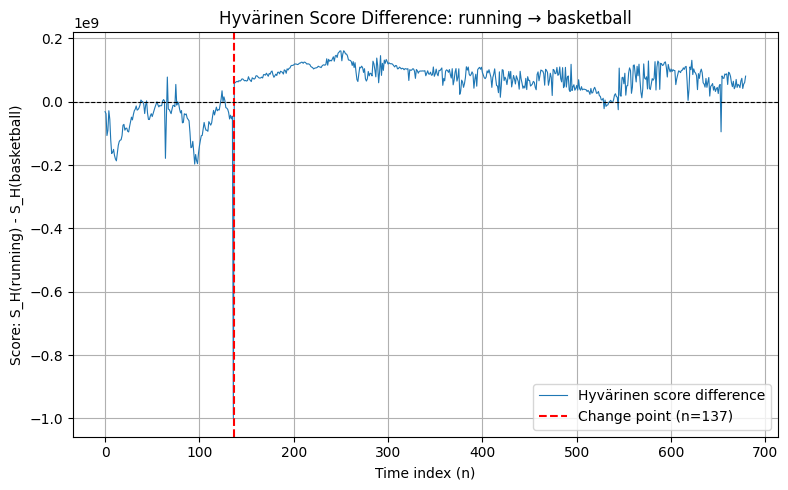

[running region] Mean: -64443592.0000
[basketball region] Mean: 81682368.0000


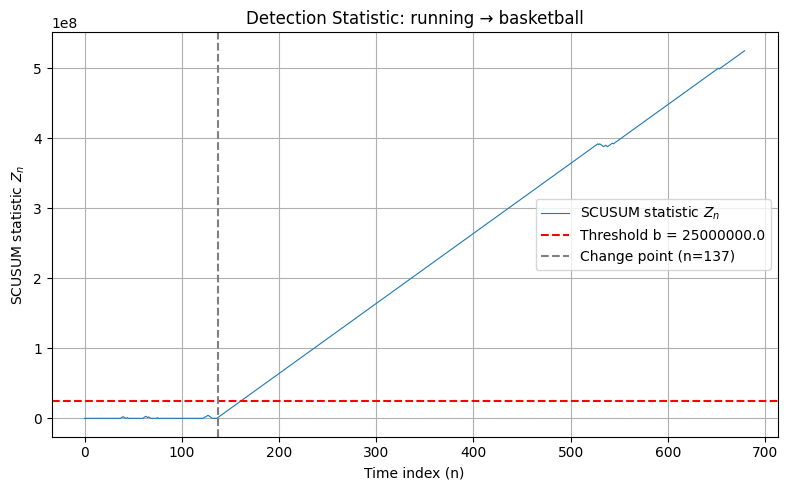

Change detected at n = 161 (threshold b = 25000000.0), delay = 24


In [49]:
if __name__ == "__main__":
    
    # === TRAINING (optional) ===
    # for class_name, trials in training_sets.items():
    #     train_model(class_name, trials)

    # === TESTING ===
    pairs_to_test = [
        ("running", "basketball", "35", "26", "06", "15"),
        # ( "basketball", "jumping", "06", "15","13", "42"),
        # ("running", "jumping", "35", "26", "13", "42"),
    ]


    for P0_class, P1_class, P0_subj, P0_trial, P1_subj, P1_trial in pairs_to_test:
        hybrid_path, T0 = generate_hybrid_path(P0_class, P1_class, P0_subj, P0_trial, P1_subj, P1_trial, save_dir)
        test_hyvarinen_difference(P0_class, P1_class, hybrid_path, T0)



=== Generating hybrid path: basketball → jumping ===
Saved hybrid path to: C:\Users\chenw\OneDrive - University of Pittsburgh\_score network code\Markov chain neumeric\CMU motion capture\training_amc\hybrid_path_basketball_to_jumping.pt
Shape: torch.Size([943, 93]) = (544+399, 93)

=== Testing basketball → jumping ===
Saved score difference to: C:\Users\chenw\OneDrive - University of Pittsburgh\_score network code\Markov chain neumeric\CMU motion capture\training_amc\score_diff_basketball_to_jumping.pt


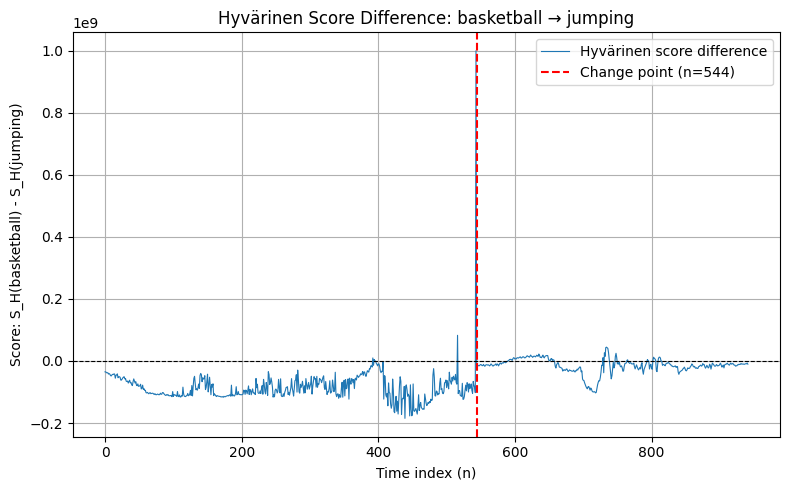

[basketball region] Mean: -85200536.0000
[jumping region] Mean: -14555240.0000


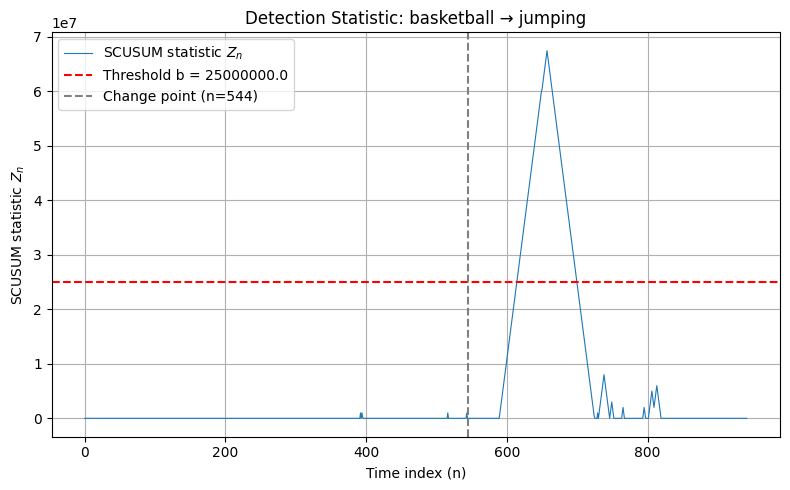

Change detected at n = 615 (threshold b = 25000000.0), delay = 71


In [50]:
# === TESTING ===
pairs_to_test = [
    # ("running", "basketball", "35", "26", "06", "15"),
    ( "basketball", "jumping", "06", "15","13", "42"),
    # ("running", "jumping", "35", "26", "13", "42"),
]


for P0_class, P1_class, P0_subj, P0_trial, P1_subj, P1_trial in pairs_to_test:
    hybrid_path, T0 = generate_hybrid_path(P0_class, P1_class, P0_subj, P0_trial, P1_subj, P1_trial, save_dir)
    test_hyvarinen_difference(P0_class, P1_class, hybrid_path, T0)


=== Generating hybrid path: running → jumping ===
Saved hybrid path to: C:\Users\chenw\OneDrive - University of Pittsburgh\_score network code\Markov chain neumeric\CMU motion capture\training_amc\hybrid_path_running_to_jumping.pt
Shape: torch.Size([536, 93]) = (137+399, 93)

=== Testing running → jumping ===
Saved score difference to: C:\Users\chenw\OneDrive - University of Pittsburgh\_score network code\Markov chain neumeric\CMU motion capture\training_amc\score_diff_running_to_jumping.pt


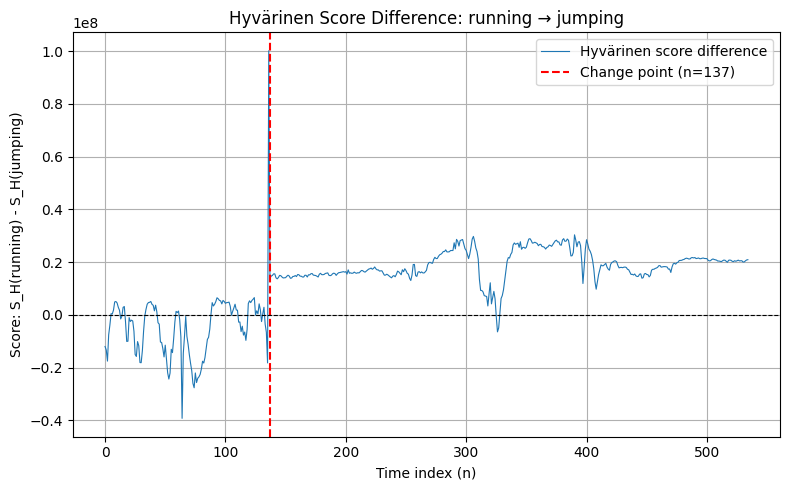

[running region] Mean: -4388763.5000
[jumping region] Mean: 18901354.0000


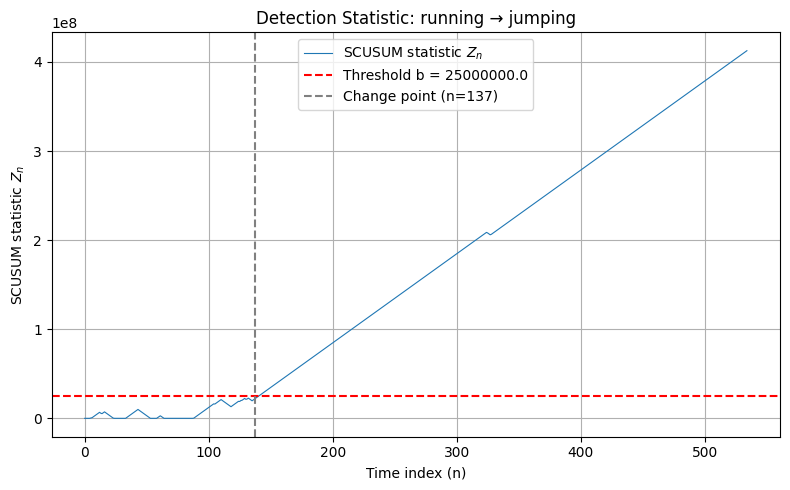

Change detected at n = 141 (threshold b = 25000000.0), delay = 4


In [51]:
# === TESTING ===
pairs_to_test = [
    # ("running", "basketball", "35", "26", "06", "15"),
    # ( "basketball", "jumping", "06", "15","13", "42"),
    ("running", "jumping", "35", "26", "13", "42"),
]


for P0_class, P1_class, P0_subj, P0_trial, P1_subj, P1_trial in pairs_to_test:
    hybrid_path, T0 = generate_hybrid_path(P0_class, P1_class, P0_subj, P0_trial, P1_subj, P1_trial, save_dir)
    test_hyvarinen_difference(P0_class, P1_class, hybrid_path, T0)